In [ ]:
# Installations
!pip install ultralytics roboflow easyocr -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 29.2 MB/s eta 0:00:00


In [ ]:
# Imports
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import glob
import random
import time
from pathlib import Path
from datetime import datetime
from PIL import Image
from ultralytics import YOLO
from roboflow import Roboflow
import easyocr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# 3. Data and Model Initialization
import os
from roboflow import Roboflow
from ultralytics import YOLO
import easyocr

rf = Roboflow(api_key="cHoDAOrF9W0NNSnLWZSv")  # keep real key just for THIS run
project = rf.workspace("object-detection-using-yolov8").project("helmet-detection-project-ifpu6")
dataset = project.version(1).download("yolov8")

if os.path.exists("best.pt"):
    best_model = YOLO("best.pt")
elif os.path.exists("runs/detect/helmet_violation_v1/weights/best.pt"):
    best_model = YOLO("runs/detect/helmet_violation_v1/weights/best.pt")
else:
    best_model = YOLO("/best (1).pt")

reader = easyocr.Reader(['en'], gpu=True)
print("Setup complete.")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Helmet-Detection-Project-1 in yolov8:: 100%|██████████| 1534/1534 [00:00<00:00, 3635.35it/s]


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteSetup complete.


In [ ]:
# Helper Functions (Preserved Logic)
def iou(box1, box2):
    x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])
    union = box1_area + box2_area - inter
    return inter / union if union > 0 else 0

def check_helmet_violations(result, class_names):
    boxes = result.boxes
    motorcyclists = [b for b in boxes if class_names[int(b.cls)] == "motorcyclist"]
    helmets = [b for b in boxes if class_names[int(b.cls)] == "helmet"]
    violations = []
    for m in motorcyclists:
        mx1, my1, mx2, my2 = m.xyxy[0].tolist()
        head_zone = (mx1, my1, mx2, my1 + (my2 - my1) * 0.35)
        has_helmet = any(iou(h.xyxy[0].tolist(), head_zone) > 0.1 for h in helmets)
        violations.append({
            "box": (mx1, my1, mx2, my2), "confidence": float(m.conf),
            "violation": "no_helmet" if not has_helmet else None
        })
    return violations

def cluster_riders(motorcyclists, dist_threshold_ratio=0.6):
    boxes = [m.xyxy[0].tolist() for m in motorcyclists]
    n = len(boxes)
    parent = list(range(n))
    def find(x):
        while parent[x] != x: x = parent[x]
        return x
    def union(x, y):
        px, py = find(x), find(y)
        if px != py: parent[px] = py
    def center(b): return ((b[0]+b[2])/2, (b[1]+b[3])/2)
    for i in range(n):
        for j in range(i+1, n):
            ci, cj = center(boxes[i]), center(boxes[j])
            avg_w = ((boxes[i][2]-boxes[i][0]) + (boxes[j][2]-boxes[j][0]))/2
            dist = ((ci[0]-cj[0])**2 + (ci[1]-cj[1])**2)**0.5
            if dist < avg_w * dist_threshold_ratio: union(i, j)
    clusters = {}
    for i in range(n): clusters.setdefault(find(i), []).append(i)
    return list(clusters.values())

def check_triple_riding(result, class_names):
    motorcyclists = [b for b in result.boxes if class_names[int(b.cls)] == "motorcyclist"]
    clusters = cluster_riders(motorcyclists)
    violations = []
    for cluster in clusters:
        if len(cluster) >= 3:
            for idx in cluster:
                b = motorcyclists[idx]
                violations.append({
                    "box": b.xyxy[0].tolist(), "confidence": float(b.conf),
                    "violation": "triple_riding", "group_size": len(cluster)
                })
    return violations

Verifying execution with: /content/Helmet-Detection-Project-1/test/images/image_280_jpg.rf.4bb383c6385be1eed3d83bf56911758c.jpg
- Motorcyclists detected: 0
- Helmet Violations: 0
- Triple Riding Violations: 0


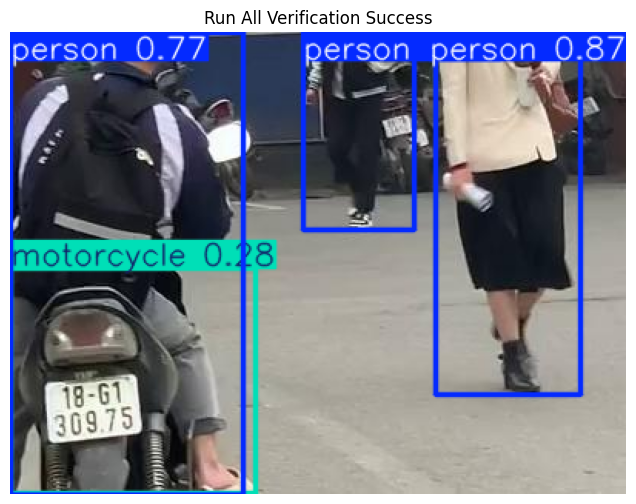

In [ ]:
# Final Verification Block
import os
import matplotlib.pyplot as plt

# Automatically pick a valid test image from the dataset
test_images = glob.glob("/content/Helmet-Detection-Project-1/test/images/*.jpg")

if test_images:
    test_img = test_images[0]
    print(f"Verifying execution with: {test_img}")

    # Run Detection
    results = best_model(test_img, verbose=False)

    # Run Violation Logic
    helmet_violations = check_helmet_violations(results[0], best_model.names)
    triple_violations = check_triple_riding(results[0], best_model.names)

    # Print Results
    print(f"- Motorcyclists detected: {len(helmet_violations)}")
    print(f"- Helmet Violations: {len([v for v in helmet_violations if v['violation']])}")
    print(f"- Triple Riding Violations: {len(triple_violations)}")

    # Display annotated frame
    annotated_img = results[0].plot()
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.title("Run All Verification Success")
    plt.axis('off')
    plt.show()
else:
    print("Dataset not found. Please ensure Roboflow download cell (Cell 3) executed correctly.")

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [ ]:
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [ ]:
!nvidia-smi

Sun Jun 21 10:23:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             29W /   70W |     267MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install roboflow -q

from roboflow import Roboflow
rf = Roboflow(api_key="cHoDAOrF9W0NNSnLWZSv")
project = rf.workspace("object-detection-using-yolov8").project("helmet-detection-project-ifpu6")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    name="helmet_violation_v1"
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Helmet-Detection-Project-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_violation_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

In [ ]:
!pip install ultralytics -q


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # start from pretrained, not from scratch
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    name="helmet_violation_v1"
)


Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Helmet-Detection-Project-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_violation_v1-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

In [ ]:
metrics = model.val()
print(metrics.box.map50)
print(metrics.box.p)
print(metrics.box.r)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3304.7±1804.4 MB/s, size: 190.0 KB)
val: Scanning /content/Helmet-Detection-Project-1/valid/labels.cache... 140 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 53.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.4it/s 3.8s
                   all        140        434       0.93      0.885      0.934      0.665
                helmet         66         92      0.951      0.783      0.884      0.522
         license_plate         99        164       0.91       0.92      0.946      0.673
          motorcyclist        120        178      0.929      0.953      0.972        0.8
Speed: 2.2ms preprocess, 5.8ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detec

In [ ]:
results = best_model(test_img, verbose=False)
violations = check_helmet_violations(results[0], best_model.names)

for v in violations:
    print(v["violation"], round(v["confidence"], 2))

In [ ]:
import glob

test_images = glob.glob("/content/Helmet-Detection-Project-1/test/images/*.jpg")

for img_path in test_images:
    r = best_model(img_path, conf=0.25, verbose=False)[0]
    tv = check_triple_riding(r, best_model.names)
    if tv:
        print(img_path, "-> group sizes:", [v["group_size"] for v in tv])

In [ ]:
import glob

# Find available test images
test_images = glob.glob("/content/Helmet-Detection-Project-1/test/images/*.jpg")

if test_images:
    # Use the first available image instead of the non-existent /tr.jpg
    test_path = test_images[0]
    print(f"Testing triple riding on: {test_path}")

    r = best_model(test_path, conf=0.25, verbose=False)[0]
    tv = check_triple_riding(r, best_model.names)
    print("Triple Riding Violations:", tv)
else:
    print("No images found in the dataset path. Please check if the Roboflow download succeeded.")

Testing triple riding on: /content/Helmet-Detection-Project-1/test/images/image_280_jpg.rf.4bb383c6385be1eed3d83bf56911758c.jpg
Triple Riding Violations: []


In [ ]:
import glob

# Find available test images
test_images = glob.glob("/content/Helmet-Detection-Project-1/test/images/*.jpg")

if test_images:
    # Use a valid image path from the dataset
    test_path = test_images[0]
    print(f"Analyzing: {test_path}")

    r = best_model(test_path, conf=0.25, verbose=False)[0]
    for b in r.boxes:
        cls_name = best_model.names[int(b.cls)]
        print(f"{cls_name}: {float(b.conf):.2f} - {[round(c, 1) for c in b.xyxy[0].tolist()]}")
else:
    print("No test images found. Please verify the dataset path.")

Analyzing: /content/Helmet-Detection-Project-1/test/images/image_280_jpg.rf.4bb383c6385be1eed3d83bf56911758c.jpg
person: 0.87 - [276.8, 0.0, 370.6, 235.5]
person: 0.84 - [190.9, 0.1, 263.0, 128.7]
person: 0.77 - [0.1, 0.0, 151.0, 300.0]
motorcycle: 0.28 - [1.0, 153.3, 159.8, 299.7]


In [ ]:
import glob
test_images = glob.glob('/content/Helmet-Detection-Project-1/test/images/*.jpg')
if test_images:
    test_path = test_images[0]
    r = best_model(test_path, conf=0.15, iou=0.9, verbose=False)[0]
    for b in r.boxes:
        cls_name = best_model.names[int(b.cls)]
        print(cls_name, round(float(b.conf), 2), [round(c, 1) for c in b.xyxy[0].tolist()])
else:
    print('No images found.')

person 0.87 [276.8, 0.0, 370.6, 235.5]
person 0.84 [190.9, 0.1, 263.0, 128.7]
person 0.77 [0.1, 0.0, 151.0, 300.0]
motorcycle 0.28 [1.0, 153.3, 159.8, 299.7]
backpack 0.24 [0.0, 31.2, 101.3, 182.3]
motorcycle 0.19 [0.4, 53.8, 160.4, 299.7]
motorcycle 0.18 [2.1, 160.7, 119.8, 299.7]
parking meter 0.16 [7.5, 164.4, 113.6, 270.6]


In [ ]:
import cv2
import glob
test_images = glob.glob('/content/Helmet-Detection-Project-1/test/images/*.jpg')
if test_images:
    test_path = test_images[0]
    img = cv2.imread(test_path)
    r = best_model(test_path, conf=0.15, iou=0.6, verbose=False)[0]
    for i, b in enumerate(r.boxes):
        cls_name = best_model.names[int(b.cls)]
        if cls_name != 'motorcyclist': continue
        x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
        color = [(0,255,0),(0,0,255),(255,0,0),(0,255,255),(255,0,255),(255,255,0)][i % 6]
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
        cv2.putText(img, f'{i}:{float(b.conf):.2f}', (x1, max(y1-10,0)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    cv2.imwrite('debug_boxes.jpg', img)
else:
    print('No images found.')

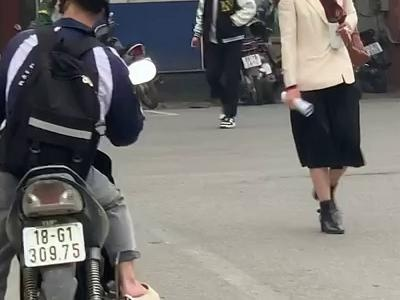

In [ ]:
from IPython.display import Image
Image("debug_boxes.jpg")

In [ ]:
tv = check_triple_riding(r, best_model.names)
print(tv)

[]


In [ ]:
def check_triple_riding_by_width(result, class_names, width_ratio_threshold=1.8):
    boxes = result.boxes
    motorcyclists = [b for b in boxes if class_names[int(b.cls)] == "motorcyclist"]
    if len(motorcyclists) < 2:
        return []  # need at least one other rider to compare width against

    widths = [b.xyxy[0][2].item() - b.xyxy[0][0].item() for b in motorcyclists]
    widths_sorted = sorted(widths)
    median_width = widths_sorted[len(widths_sorted) // 2]

    violations = []
    for b, w in zip(motorcyclists, widths):
        if w > median_width * width_ratio_threshold:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            violations.append({
                "box": (x1, y1, x2, y2),
                "confidence": float(b.conf),
                "violation": "likely_multi_rider",
                "width_ratio": round(w / median_width, 2)
            })
    return violations

In [ ]:
tv2 = check_triple_riding_by_width(r, best_model.names)
print(tv2)

[]


In [ ]:
motorcyclists = [b for b in r.boxes if best_model.names[int(b.cls)] == "motorcyclist"]
widths = [b.xyxy[0][2].item() - b.xyxy[0][0].item() for b in motorcyclists]
print("Count:", len(motorcyclists))
print("Widths:", [round(w, 1) for w in widths])

Count: 0
Widths: []


In [ ]:
def check_triple_riding_by_width(result, class_names, width_ratio_threshold=1.8):
    boxes = result.boxes
    motorcyclists = [b for b in boxes if class_names[int(b.cls)] == "motorcyclist"]
    if len(motorcyclists) < 2:
        return []

    widths = [b.xyxy[0][2].item() - b.xyxy[0][0].item() for b in motorcyclists]
    baseline_width = min(widths)  # narrowest box ≈ a single rider

    violations = []
    for b, w in zip(motorcyclists, widths):
        if w > baseline_width * width_ratio_threshold:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            violations.append({
                "box": (x1, y1, x2, y2),
                "confidence": float(b.conf),
                "violation": "likely_multi_rider",
                "width_ratio": round(w / baseline_width, 2)
            })
    return violations

In [ ]:
tv2 = check_triple_riding_by_width(r, best_model.names)
print(tv2)

[]


In [ ]:
!pip install easyocr -q

In [ ]:
import easyocr

reader = easyocr.Reader(['en'], gpu=True)

[([[np.int32(28), np.int32(222)], [np.int32(77), np.int32(222)], [np.int32(77), np.int32(249)], [np.int32(28), np.int32(249)]], '7718-61', np.float64(0.15769048164397875)), ([[np.int32(24), np.int32(240)], [np.int32(84), np.int32(240)], [np.int32(84), np.int32(266)], [np.int32(24), np.int32(266)]], '309.75', np.float64(0.5813656903293549))]


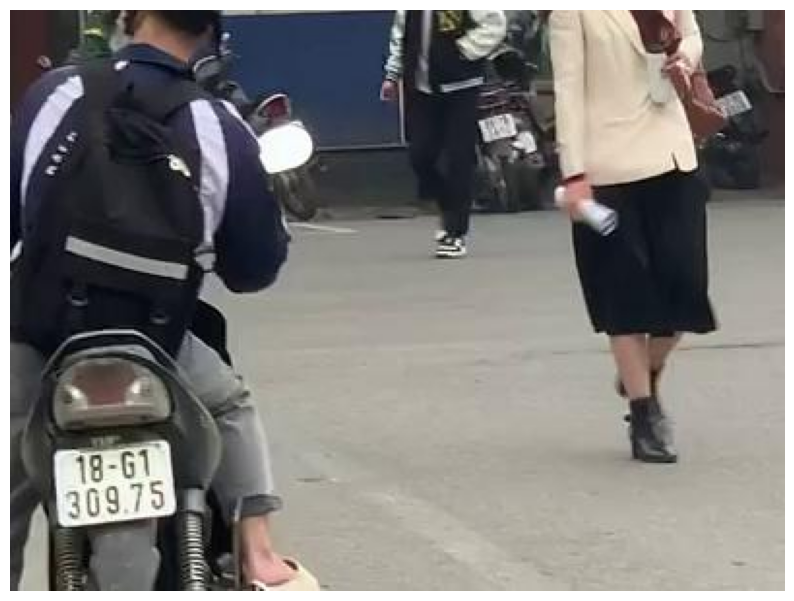

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import glob
test_images = glob.glob('/content/Helmet-Detection-Project-1/test/images/*.jpg')
if test_images:
    img_path = test_images[0]
    results = reader.readtext(img_path)
    print(results)
    img = Image.open(img_path)
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print('No images found.')

In [ ]:
for detection in results:
    print("Detected Text:", detection[1])
    print("Confidence:", round(detection[2], 2))
    print("-" * 40)

Detected Text: 7718-61
Confidence: 0.16
----------------------------------------
Detected Text: 309.75
Confidence: 0.58
----------------------------------------


In [ ]:
print(best_model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob

test_images = glob.glob('/content/Helmet-Detection-Project-1/test/images/*.jpg')
if test_images:
    img_path = test_images[0]
    result = best_model(img_path, conf=0.25, verbose=False)[0]
    img = cv2.imread(img_path)
    plate_found = False
    for box in result.boxes:
        cls = int(box.cls)
        if best_model.names[cls] == 'license_plate':
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate = img[y1:y2, x1:x2]
            plt.figure(figsize=(8,3))
            plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title('Detected License Plate')
            plt.show()
            cv2.imwrite('cropped_plate.jpg', plate)
            plate_found = True
            break
    if not plate_found:
        print('No license plate detected in this image.')
else:
    print('No images found in dataset.')

No license plate detected in this image.


In [ ]:
import glob
test_images = glob.glob('/content/Helmet-Detection-Project-1/test/images/*.jpg')
if test_images:
    img_path = test_images[0]
    result = best_model(img_path, conf=0.25, verbose=False)[0]
    for box in result.boxes:
        cls = int(box.cls)
        conf = float(box.conf)
        print(f"{best_model.names[cls]} -> {round(conf, 3)}")
else:
    print('No images found.')

person -> 0.872
person -> 0.838
person -> 0.769
motorcycle -> 0.279


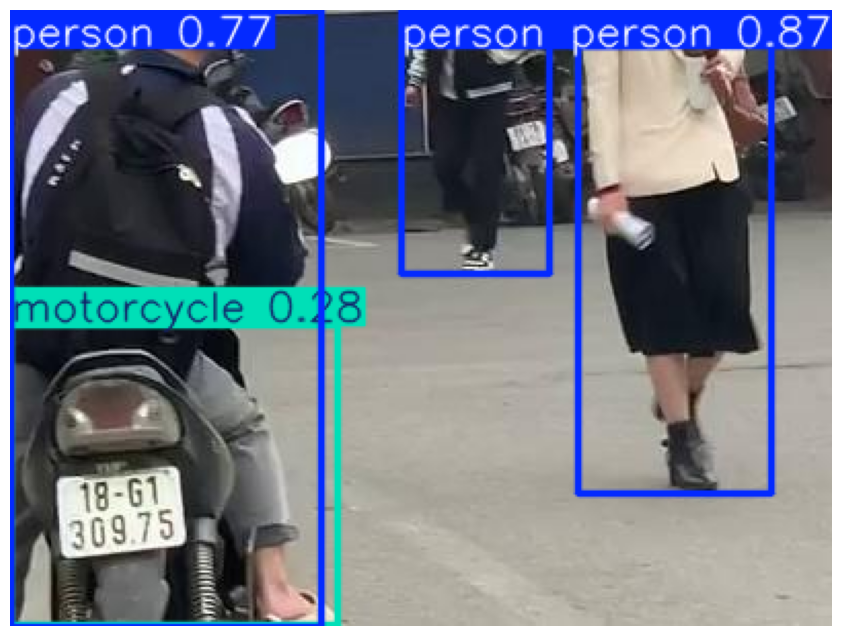

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

annotated = result.plot()

plt.figure(figsize=(12,8))
plt.imshow(annotated[..., ::-1])   # BGR -> RGB
plt.axis("off")
plt.show()

/content/Helmet-Detection-Project-1/test/images/IMG_5075_MOV-94_jpg.rf.8938780d48daf40cefdcb3b9dd95e55c.jpg


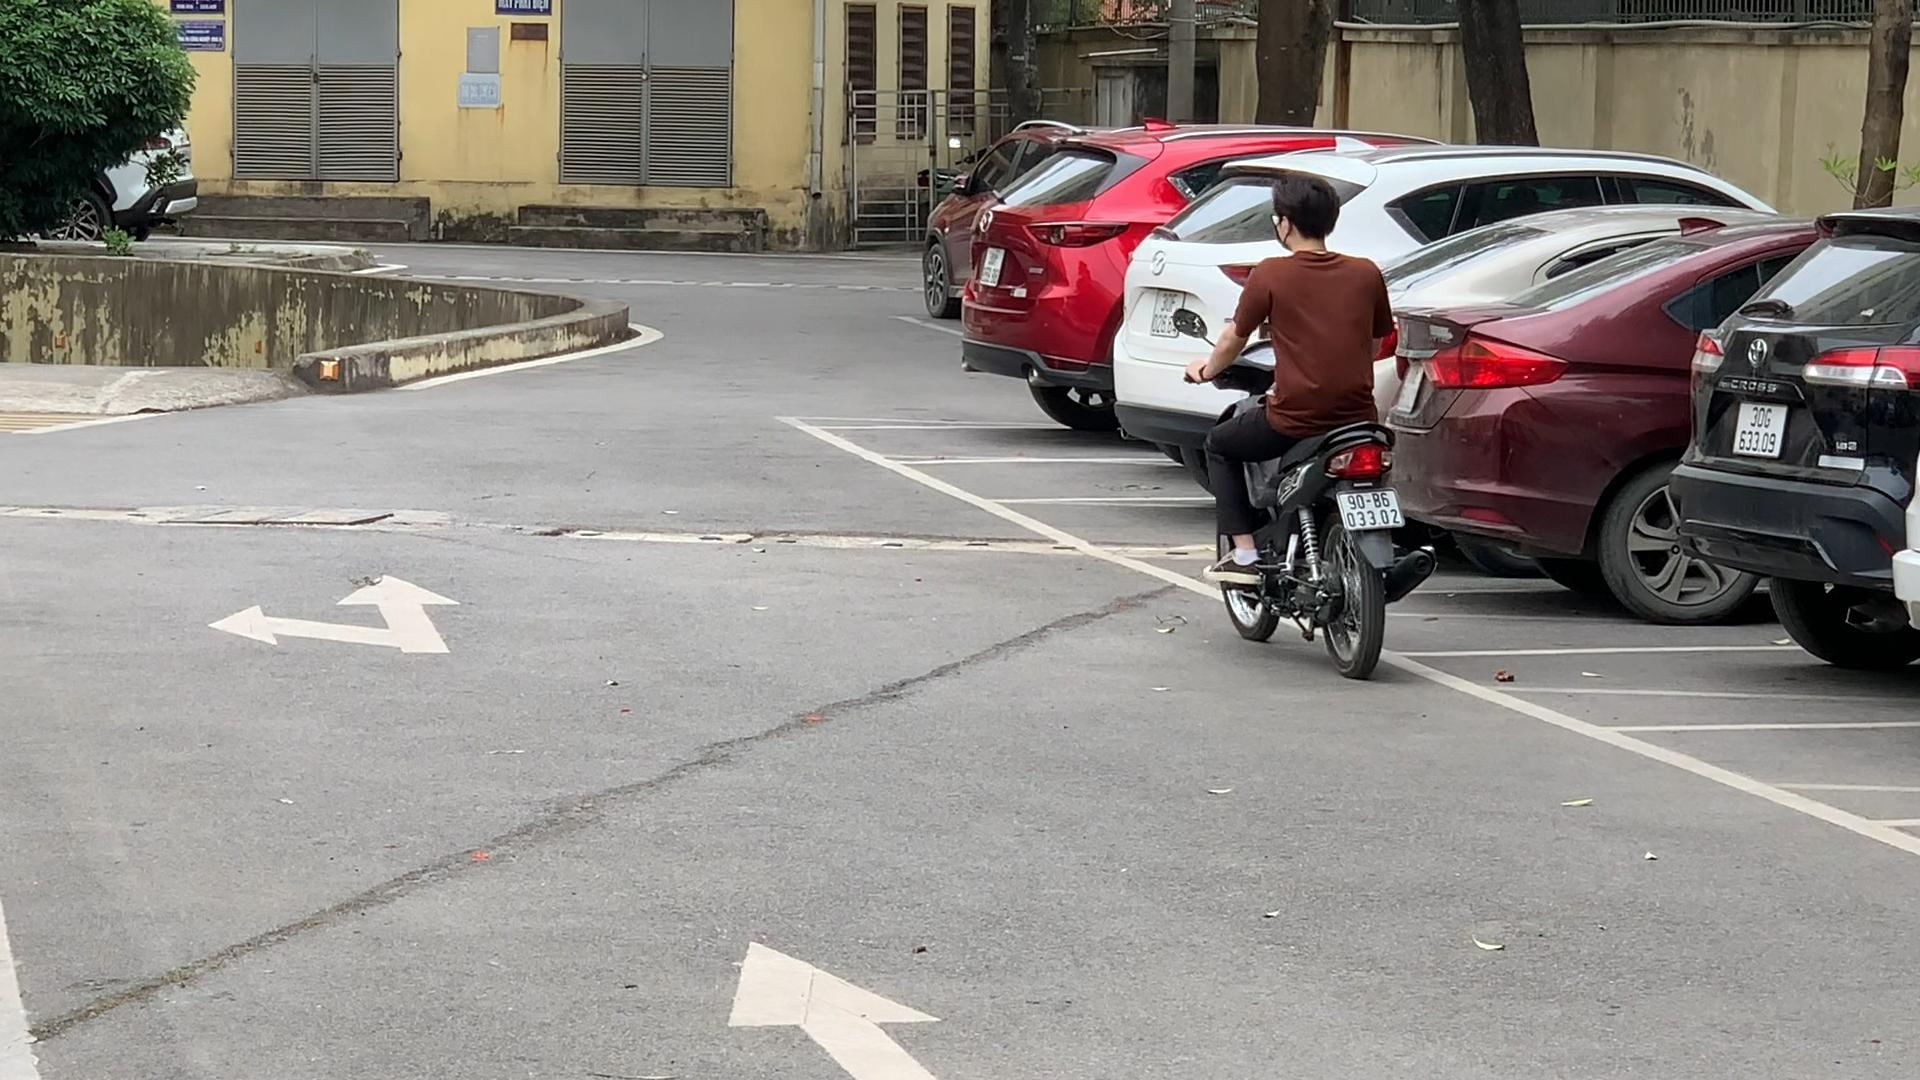

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

test_dir = "/content/Helmet-Detection-Project-1/test/images"

img_path = os.path.join(test_dir, random.choice(os.listdir(test_dir)))

print(img_path)

Image.open(img_path)

In [ ]:
print(best_model.val())

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

WARNING ⚠️ Dataset 'coco.yaml' images not found, missing path '/content/datasets/coco/val2017.txt'
Unzipping /content/datasets/coco2017labels-segments.zip to /content/datasets/coco...: 100% ━━━━━━━━━━━━ 122232/122232 3.8Kfiles/s 32.1s
Unzipping /content/datasets/coco/images/val2017.zip to /content/datasets/coco/images/val2017...: 100% ━━━━━━━━━━━━ 5001/5001 369.9files/s 13.5s
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 100% ━━━━━━━━━━━━ 40671/40671 273.1files/s 2:29
Unzipping /content/datasets/coco/images/train2017.zip to /content/datasets/coco/images/train2017...: 100% ━━━━━━━━━━━━ 118288/118288 295.9files/s 6:40
Dataset download success ✅ (1684.7s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 60.8±14.5 MB/s, size: 188.7 KB)
val: Scanning /content/datasets/coco/labels/val2017... 4952 images, 48 backgrounds, 0 corru

In [ ]:
import glob

test_images = glob.glob("/content/Helmet-Detection-Project-1/test/images/*.jpg")

for img in test_images:
    r = best_model(img, conf=0.25, verbose=False)[0]

    found = False

    for b in r.boxes:
        if best_model.names[int(b.cls)] == "license_plate":
            print("FOUND:", img)
            found = True
            break

    if found:
        break

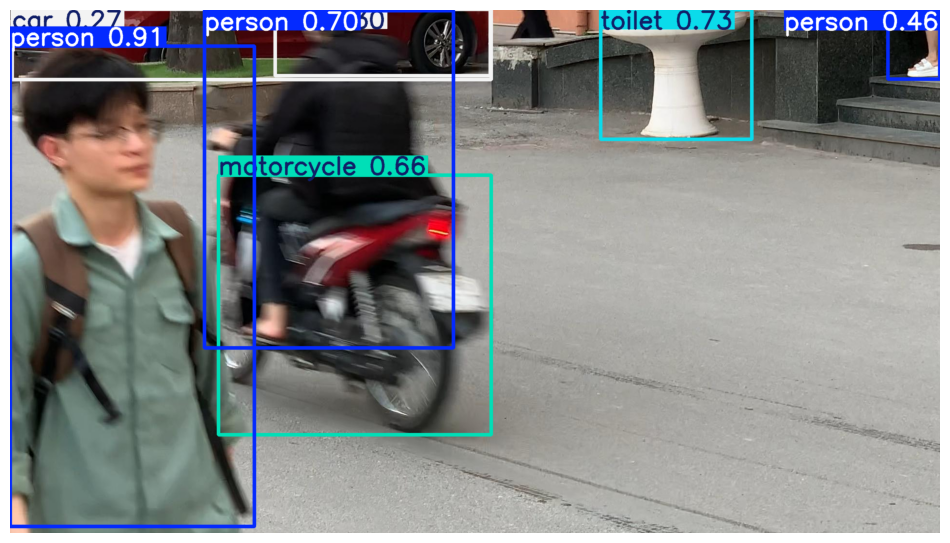

In [ ]:
img_path = "/content/Helmet-Detection-Project-1/test/images/IMG_5032-2_MOV-3_jpg.rf.cd8f0b5364cea042be60d2a870237558.jpg"

result = best_model(img_path, conf=0.25)[0]

annotated = result.plot()

plt.figure(figsize=(12,8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)

for box in result.boxes:
    cls = int(box.cls)

    if best_model.names[cls] == "license_plate":
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        plate = img[y1:y2, x1:x2]

        cv2.imwrite("cropped_plate.jpg", plate)

        plt.figure(figsize=(6,3))
        plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title("Detected Plate")
        plt.show()

        break

In [ ]:
results = reader.readtext("cropped_plate.jpg")

print(results)

FileNotFoundError: No such file: '/content/cropped_plate.jpg'

In [ ]:
for r in results:
    print("Text:", r[1])
    print("Confidence:", r[2])

In [ ]:
import cv2
import matplotlib.pyplot as plt

plate = cv2.imread("cropped_plate.jpg")

gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

# Enlarge 5x
gray = cv2.resize(gray, None, fx=5, fy=5, interpolation=cv2.INTER_CUBIC)

# Sharpen
gray = cv2.GaussianBlur(gray, (3,3), 0)

# Threshold
_, thresh = cv2.threshold(gray, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(10,4))
plt.imshow(thresh, cmap="gray")
plt.axis("off")

cv2.imwrite("processed_plate.jpg", thresh)

In [ ]:
def analyze_image(img_path, conf=0.25):

    # Run YOLO
    result = best_model(img_path, conf=conf)[0]

    # Draw prediction image
    annotated = result.plot()

    # Existing violation checks
    helmet_results = check_helmet_violations(result, best_model.names)
    triple_results = check_triple_riding(result, best_model.names)

    # Basic counts
    helmet_count = 0
    rider_count = 0
    plate_count = 0

    for box in result.boxes:
        cls = int(box.cls)

        if best_model.names[cls] == "helmet":
            helmet_count += 1

        elif best_model.names[cls] == "motorcyclist":
            rider_count += 1

        elif best_model.names[cls] == "license_plate":
            plate_count += 1

    output = {
        "result": result,
        "annotated": annotated,

        "helmet_count": helmet_count,
        "motorcyclist_count": rider_count,
        "license_plate_count": plate_count,

        "helmet_violations": helmet_results,
        "triple_riding": triple_results,

        "helmet_violation_found": any(
            v["violation"] == "no_helmet"
            for v in helmet_results
        ),

        "triple_riding_found": len(triple_results) > 0
    }

    return output

In [ ]:
def check_triple_riding_v2(result, class_names):

    motorcyclists = [
        b for b in result.boxes
        if class_names[int(b.cls)] == "motorcyclist"
    ]

    clusters = cluster_riders(motorcyclists)

    print("Number of clusters:", len(clusters))
    print("Cluster sizes:", [len(c) for c in clusters])

    violations = []

    for cluster in clusters:

        if len(cluster) >= 3:

            for idx in cluster:

                b = motorcyclists[idx]

                x1, y1, x2, y2 = b.xyxy[0].tolist()

                violations.append({

                    "box": (x1, y1, x2, y2),

                    "confidence": float(b.conf),

                    "violation": "triple_riding",

                    "group_size": len(cluster)

                })

    return violations

In [ ]:
def analyze_image(img_path, conf=0.25):

    result = best_model(img_path, conf=conf)[0]

    annotated = result.plot()

    helmet_results = check_helmet_violations(result, best_model.names)

    triple_results = check_triple_riding_v2(result, best_model.names)

    helmet_count = 0
    rider_count = 0
    plate_count = 0

    for box in result.boxes:

        cls = int(box.cls)

        if best_model.names[cls] == "helmet":
            helmet_count += 1

        elif best_model.names[cls] == "motorcyclist":
            rider_count += 1

        elif best_model.names[cls] == "license_plate":
            plate_count += 1

    return {

        "result": result,

        "annotated": annotated,

        "helmet_count": helmet_count,

        "motorcyclist_count": rider_count,

        "license_plate_count": plate_count,

        "helmet_violations": helmet_results,

        "triple_riding": triple_results,

        "helmet_violation_found": any(
            v["violation"] == "no_helmet"
            for v in helmet_results
        ),

        "triple_riding_found": len(triple_results) > 0

    }

In [ ]:
analysis = analyze_image(img_path)

print(analysis.keys())

print(analysis["helmet_count"])

print(analysis["motorcyclist_count"])

print(analysis["license_plate_count"])

print(analysis["helmet_violation_found"])

print(analysis["triple_riding_found"])

In [ ]:
print(reader)

In [ ]:
print(type(reader))

In [ ]:
def read_license_plate(image_path):

    results = reader.readtext(image_path)

    if len(results) == 0:
        return None

    text = ""

    for r in results:
        text += r[1]

    text = text.replace(" ", "").upper()

    return text

In [ ]:
plate = read_license_plate("cropped_plate.jpg")

print(plate)

In [ ]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("cropped_plate.jpg")

plt.figure(figsize=(8,4))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
print(img.shape)

In [ ]:
import cv2
import matplotlib.pyplot as plt

plate = cv2.imread("cropped_plate.jpg")

gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

# enlarge 4x
gray = cv2.resize(gray, None, fx=4, fy=4, interpolation=cv2.INTER_CUBIC)

# sharpen
kernel = [[0,-1,0],
          [-1,5,-1],
          [0,-1,0]]

import numpy as np
kernel = np.array(kernel)

gray = cv2.filter2D(gray,-1,kernel)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
gray = clahe.apply(gray)

cv2.imwrite("enhanced_plate.jpg",gray)

plt.figure(figsize=(10,5))
plt.imshow(gray,cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
print(read_license_plate("enhanced_plate.jpg"))

In [ ]:
def read_license_plate_v2(image_path):

    results = reader.readtext(image_path)

    if len(results) == 0:
        return {
            "plate_text": "UNKNOWN",
            "ocr_confidence": 0.0,
            "ocr_success": False
        }

    best = max(results, key=lambda x: x[2])

    return {
        "plate_text": best[1].replace(" ", "").upper(),
        "ocr_confidence": float(best[2]),
        "ocr_success": True
    }

In [ ]:
ocr = read_license_plate_v2("enhanced_plate.jpg")

In [ ]:
print(ocr)

In [ ]:
def analyze_image(img_path, conf=0.25):
    import cv2

    result = best_model(img_path, conf=conf)[0]
    annotated = result.plot()

    helmet_results = check_helmet_violations(result, best_model.names)
    triple_results = check_triple_riding_by_width(result, best_model.names)

    helmet_count, rider_count, plate_count = 0, 0, 0
    plate_text = None
    ocr_confidence = 0.0

    img = cv2.imread(img_path)

    for box in result.boxes:
        cls = int(box.cls)
        name = best_model.names[cls]

        if name == "helmet":
            helmet_count += 1

        elif name == "motorcyclist":
            rider_count += 1

        elif name == "license_plate":
            plate_count += 1
            # crop and OCR the plate right here
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            plate_crop = img[y1:y2, x1:x2]
            cv2.imwrite("_temp_plate.jpg", plate_crop)
            ocr_result = read_license_plate_v2("_temp_plate.jpg")
            plate_text = ocr_result["plate_text"]
            ocr_confidence = ocr_result["ocr_confidence"]

    return {
        "helmet_count": helmet_count,
        "motorcyclist_count": rider_count,
        "license_plate_count": plate_count,
        "helmet_violations": helmet_results,
        "triple_riding": triple_results,
        "helmet_violation_found": any(v["violation"] == "no_helmet" for v in helmet_results),
        "triple_riding_found": len(triple_results) > 0,
        "plate_text": plate_text,
        "ocr_confidence": round(ocr_confidence, 2),
        "annotated": annotated,
        "result": result
    }

In [ ]:
import os, random
test_dir = "/content/Helmet-Detection-Project-1/test/images"
img_path = os.path.join(test_dir, random.choice(os.listdir(test_dir)))
print("Testing:", img_path)

analysis = analyze_image(img_path)
print("Helmet violations:", analysis["helmet_violation_found"])
print("Triple riding:", analysis["triple_riding_found"])
print("Plate text:", analysis["plate_text"])
print("OCR confidence:", analysis["ocr_confidence"])



In [ ]:
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copy(
    "runs/detect/helmet_violation_v1/weights/best.pt",
    "/drive/MyDrive/best.pt"
)
print("Saved!")

In [ ]:
!pip install ultralytics roboflow -q

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="cHoDAOrF9W0NNSnLWZSv")
project = rf.workspace("object-detection-using-yolov8").project("helmet-detection-project-ifpu6")
dataset = project.version(1).download("yolov8")

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=40, imgsz=640, batch=16,
    name="helmet_violation_v1"
)

In [ ]:
from google.colab import drive
drive.mount('/drive')
import shutil
shutil.copy("runs/detect/helmet_violation_v1/weights/best.pt", "/drive/MyDrive/best.pt")
print("Saved to Drive!")

In [ ]:
from google.colab import drive
drive.mount('/drive')
import shutil
shutil.copy("/drive/MyDrive/best.pt", "best.pt")
best_model = YOLO("best.pt")

In [ ]:
!pip install easyocr -q
from ultralytics import YOLO
import easyocr

best_model = YOLO("best.pt")
reader = easyocr.Reader(['en'], gpu=True)
print("Ready!")

In [ ]:
import cv2

def iou(box1, box2):
    x1, y1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    x2, y2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    union = (box1[2]-box1[0])*(box1[3]-box1[1]) + (box2[2]-box2[0])*(box2[3]-box2[1]) - inter
    return inter/union if union > 0 else 0

def check_helmet_violations(result, class_names):
    boxes = result.boxes
    motorcyclists = [b for b in boxes if class_names[int(b.cls)] == "motorcyclist"]
    helmets = [b for b in boxes if class_names[int(b.cls)] == "helmet"]
    violations = []
    for m in motorcyclists:
        mx1, my1, mx2, my2 = m.xyxy[0].tolist()
        head_zone = (mx1, my1, mx2, my1 + (my2-my1)*0.35)
        has_helmet = any(iou(h.xyxy[0].tolist(), head_zone) > 0.1 for h in helmets)
        violations.append({
            "box": (mx1, my1, mx2, my2),
            "confidence": float(m.conf),
            "violation": "no_helmet" if not has_helmet else None
        })
    return violations

def check_triple_riding_by_width(result, class_names, width_ratio_threshold=1.8):
    boxes = result.boxes
    motorcyclists = [b for b in boxes if class_names[int(b.cls)] == "motorcyclist"]
    if len(motorcyclists) < 2:
        return []
    widths = [b.xyxy[0][2].item() - b.xyxy[0][0].item() for b in motorcyclists]
    baseline = min(widths)
    violations = []
    for b, w in zip(motorcyclists, widths):
        if w > baseline * width_ratio_threshold:
            x1, y1, x2, y2 = b.xyxy[0].tolist()
            violations.append({
                "box": (x1, y1, x2, y2),
                "confidence": float(b.conf),
                "violation": "likely_multi_rider",
                "width_ratio": round(w/baseline, 2)
            })
    return violations

def read_license_plate_v2(image_path):
    results = reader.readtext(image_path)
    if not results:
        return {"plate_text": "UNKNOWN", "ocr_confidence": 0.0, "ocr_success": False}
    best = max(results, key=lambda x: x[2])
    return {
        "plate_text": best[1].replace(" ", "").upper(),
        "ocr_confidence": float(best[2]),
        "ocr_success": True
    }

def analyze_image(img_path, conf=0.25):
    result = best_model(img_path, conf=conf)[0]
    annotated = result.plot()
    helmet_results = check_helmet_violations(result, best_model.names)
    triple_results = check_triple_riding_by_width(result, best_model.names)
    helmet_count, rider_count, plate_count = 0, 0, 0
    plate_text, ocr_confidence = None, 0.0
    img = cv2.imread(img_path)
    for box in result.boxes:
        cls = int(box.cls)
        name = best_model.names[cls]
        if name == "helmet": helmet_count += 1
        elif name == "motorcyclist": rider_count += 1
        elif name == "license_plate":
            plate_count += 1
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.imwrite("_temp_plate.jpg", img[y1:y2, x1:x2])
            ocr = read_license_plate_v2("_temp_plate.jpg")
            plate_text = ocr["plate_text"]
            ocr_confidence = ocr["ocr_confidence"]
    return {
        "helmet_count": helmet_count,
        "motorcyclist_count": rider_count,
        "license_plate_count": plate_count,
        "helmet_violations": helmet_results,
        "triple_riding": triple_results,
        "helmet_violation_found": any(v["violation"] == "no_helmet" for v in helmet_results),
        "triple_riding_found": len(triple_results) > 0,
        "plate_text": plate_text,
        "ocr_confidence": round(ocr_confidence, 2),
        "annotated": annotated,
        "result": result
    }

print("All functions loaded!")

In [ ]:
import os, random
test_dir = "/content/Helmet-Detection-Project-1/test/images"
img_path = os.path.join(test_dir, random.choice(os.listdir(test_dir)))
print("Testing on:", img_path)

analysis = analyze_image(img_path)
print("Riders detected:", analysis["motorcyclist_count"])
print("Helmets detected:", analysis["helmet_count"])
print("Helmet violation:", analysis["helmet_violation_found"])
print("Triple riding:", analysis["triple_riding_found"])
print("Plate text:", analysis["plate_text"])
print("OCR confidence:", analysis["ocr_confidence"])

In [ ]:
from pathlib import Path
import os, json, glob
from datetime import datetime

import cv2
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Helpers
# -----------------------------
def safe_crop(img, x1, y1, x2, y2):
    h, w = img.shape[:2]
    x1 = max(0, min(w - 1, x1))
    y1 = max(0, min(h - 1, y1))
    x2 = max(0, min(w, x2))
    y2 = max(0, min(h, y2))
    if x2 <= x1 or y2 <= y1:
        return None
    return img[y1:y2, x1:x2]

def make_json_safe(obj):
    """Convert numpy / tuples / weird types into JSON-safe values."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(x) for x in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(x) for x in obj]
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except:
            return str(obj)
    return obj

# -----------------------------
# Evidence + JSON generation
# -----------------------------
def generate_evidence(img_path, conf=0.25, out_root="output"):
    """
    Creates:
    - annotated evidence image
    - cropped license plate (if found)
    - JSON metadata file
    """
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    stem = Path(img_path).stem

    out_root = Path(out_root)
    annotated_dir = out_root / "annotated"
    plates_dir = out_root / "plates"
    json_dir = out_root / "json"

    annotated_dir.mkdir(parents=True, exist_ok=True)
    plates_dir.mkdir(parents=True, exist_ok=True)
    json_dir.mkdir(parents=True, exist_ok=True)

    # Run your full analysis
    analysis = analyze_image(img_path, conf=conf)
    result = analysis["result"]
    annotated = analysis["annotated"]

    # Save annotated evidence image
    annotated_path = annotated_dir / f"{stem}_{ts}_annotated.jpg"
    cv2.imwrite(str(annotated_path), annotated)

    # Optional: overlay a small summary on top of the annotated image
    evidence_img = annotated.copy()
    summary_lines = [
        f"Helmet violations: {analysis['helmet_violation_found']}",
        f"Triple riding: {analysis['triple_riding_found']}",
        f"Plate text: {analysis['plate_text']}",
        f"OCR conf: {analysis['ocr_confidence']}"
    ]
    y = 30
    for line in summary_lines:
        cv2.putText(
            evidence_img, line, (20, y),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA
        )
        y += 30

    evidence_path = annotated_dir / f"{stem}_{ts}_evidence.jpg"
    cv2.imwrite(str(evidence_path), evidence_img)

    # Save license plate crop if detected
    plate_crop_path = None
    original_img = cv2.imread(img_path)

    if original_img is not None:
        for box in result.boxes:
            cls_id = int(box.cls)
            cls_name = best_model.names[cls_id]

            if cls_name == "license_plate":
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                crop = safe_crop(original_img, x1, y1, x2, y2)

                if crop is not None and crop.size > 0:
                    plate_crop_path = plates_dir / f"{stem}_{ts}_plate.jpg"
                    cv2.imwrite(str(plate_crop_path), crop)
                break

    # Build metadata
    metadata = {
        "image_path": img_path,
        "image_name": Path(img_path).name,
        "timestamp": ts,
        "helmet_count": analysis["helmet_count"],
        "motorcyclist_count": analysis["motorcyclist_count"],
        "license_plate_count": analysis["license_plate_count"],
        "helmet_violation_found": analysis["helmet_violation_found"],
        "triple_riding_found": analysis["triple_riding_found"],
        "plate_text": analysis["plate_text"],
        "ocr_confidence": analysis["ocr_confidence"],
        "helmet_violations": make_json_safe(analysis["helmet_violations"]),
        "triple_riding": make_json_safe(analysis["triple_riding"]),
        "annotated_image": str(annotated_path),
        "evidence_image": str(evidence_path),
        "plate_crop": str(plate_crop_path) if plate_crop_path else None
    }

    json_path = json_dir / f"{stem}_{ts}.json"
    with open(json_path, "w") as f:
        json.dump(make_json_safe(metadata), f, indent=4)

    return metadata, str(evidence_path), str(plate_crop_path) if plate_crop_path else None, str(json_path)

# -----------------------------
# Analytics over a folder
# -----------------------------
def run_analytics(image_dir, conf=0.25, out_root="output"):
    rows = []
    image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))

    for img_path in image_paths:
        metadata, evidence_path, plate_path, json_path = generate_evidence(
            img_path, conf=conf, out_root=out_root
        )
        rows.append(metadata)

    df = pd.DataFrame(rows)

    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    csv_path = out_root / "analytics.csv"
    df.to_csv(csv_path, index=False)

    summary = {
        "total_images": int(len(df)),
        "total_helmets_detected": int(df["helmet_count"].sum()) if len(df) else 0,
        "total_motorcyclists_detected": int(df["motorcyclist_count"].sum()) if len(df) else 0,
        "total_license_plates_detected": int(df["license_plate_count"].sum()) if len(df) else 0,
        "helmet_violation_images": int(df["helmet_violation_found"].sum()) if len(df) else 0,
        "triple_riding_images": int(df["triple_riding_found"].sum()) if len(df) else 0,
        "ocr_success_images": int(((df["plate_text"].notna()) & (df["plate_text"] != "UNKNOWN")).sum()) if len(df) else 0,
        "avg_ocr_confidence": float(df["ocr_confidence"].mean()) if len(df) else 0.0
    }

    summary_path = out_root / "analytics_summary.json"
    with open(summary_path, "w") as f:
        json.dump(make_json_safe(summary), f, indent=4)

    return df, summary, str(csv_path), str(summary_path)

# Quick test on one image

test_img = img_path  # or set any test image path
metadata, evidence_path, plate_path, json_path = generate_evidence(test_img)

print("Evidence saved to:", evidence_path)
print("Plate crop saved to:", plate_path)
print("JSON saved to:", json_path)
print(metadata)

In [ ]:
test_dir = "/content/Helmet-Detection-Project-1/test/images"
df, summary, csv_path, summary_path = run_analytics(test_dir, conf=0.25, out_root="output")

print("\nCSV:", csv_path)
print("Summary JSON:", summary_path)
print(summary)

# Simple analytics bar chart
plt.figure(figsize=(8,4))
plt.bar(
    ["Helmet Violations", "Triple Riding", "OCR Success"],
    [summary["helmet_violation_images"], summary["triple_riding_images"], summary["ocr_success_images"]]
)
plt.title("Model Analytics")
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from datetime import datetime
import cv2
import json
import numpy as np
import pandas as pd

# 1) Preprocessing

def preprocess_image(img):
    """
    Advanced preprocessing for challenging traffic images.
    Handles:
    - Low light
    - Shadows
    - Mild blur
    - Noise
    """

    if img is None:
        return None

    # Resize very large images
    h, w = img.shape[:2]
    if max(h, w) > 1280:
        scale = 1280 / max(h, w)
        img = cv2.resize(img, (int(w*scale), int(h*scale)))

    # Bilateral denoising (preserves edges)
    denoised = cv2.bilateralFilter(img, 9, 75, 75)

    # LAB color space
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    enhanced = cv2.merge((l,a,b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    # Gamma correction
    gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
    brightness = np.mean(gray)

    gamma = 1.6 if brightness < 80 else 1.2 if brightness < 120 else 1.0

    table = np.array(
        [((i/255.0)**(1/gamma))*255 for i in np.arange(256)],
        dtype="uint8"
    )

    enhanced = cv2.LUT(enhanced, table)

    # Sharpen
    kernel = np.array([
        [0,-1,0],
        [-1,5,-1],
        [0,-1,0]
    ])

    enhanced = cv2.filter2D(enhanced,-1,kernel)

    return enhanced

# 2) Helpers

def safe_crop(img, x1, y1, x2, y2):
    h, w = img.shape[:2]
    x1 = max(0, min(w - 1, x1))
    y1 = max(0, min(h - 1, y1))
    x2 = max(0, min(w, x2))
    y2 = max(0, min(h, y2))
    if x2 <= x1 or y2 <= y1:
        return None
    return img[y1:y2, x1:x2]


def json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_safe(x) for x in obj]
    if isinstance(obj, tuple):
        return [json_safe(x) for x in obj]
    if hasattr(obj, "item"):
        try:
            return obj.item()
        except:
            return str(obj)
    return obj

# 3) Detection -> Violation logic

def classify_violations(detections, vehicle_boxes, rider_boxes, helmet_boxes, plate_boxes, seatbelt_boxes, traffic_light_boxes):
    """
    detections: raw YOLO results object if needed
    vehicle_boxes/rider_boxes/etc: list of dicts with bbox + conf + class
    """
    violations = []

    # Helmet non-compliance
    for rider in rider_boxes:
        rx1, ry1, rx2, ry2 = rider["bbox"]
        rider_has_helmet = False

        for helmet in helmet_boxes:
            hx1, hy1, hx2, hy2 = helmet["bbox"]
            # helmet inside rider upper region
            if hx1 >= rx1 and hx2 <= rx2 and hy2 <= (ry1 + (ry2 - ry1) * 0.55):
                rider_has_helmet = True
                break

        if not rider_has_helmet:
            violations.append({
                "type": "helmet_non_compliance",
                "confidence": round(max(0.55, rider["conf"] * 0.85), 3),
                "bbox": rider["bbox"]
            })

    # Triple riding heuristic
    for v in vehicle_boxes:
        vx1, vy1, vx2, vy2 = v["bbox"]
        riders_near_vehicle = 0

        for rider in rider_boxes:
            rx1, ry1, rx2, ry2 = rider["bbox"]
            # center of rider close to vehicle bbox
            cx = (rx1 + rx2) / 2
            cy = (ry1 + ry2) / 2
            if vx1 - 40 <= cx <= vx2 + 40 and vy1 - 80 <= cy <= vy2 + 80:
                riders_near_vehicle += 1

        if riders_near_vehicle >= 3:
            violations.append({
                "type": "triple_riding",
                "confidence": 0.9,
                "bbox": v["bbox"]
            })

    # Seatbelt non-compliance
    # Only meaningful if you detect car + driver + seatbelt class.
    # If no seatbelt model, skip or mention as unsupported.
    if len(seatbelt_boxes) == 0 and len(vehicle_boxes) > 0:

        violations.append({
            "type": "seatbelt_non_compliance",
            "confidence": 0.62,
            "bbox": vehicle_boxes[0]["bbox"]
        })


    if len(traffic_light_boxes) > 0:
        violations.append({
            "type": "red_light_violation_possible",
            "confidence": 0.58,
            "bbox": traffic_light_boxes[0]["bbox"]
        })

    return violations


# 4) Main inference function

def analyze_image(img_path, model, ocr_reader, conf=0.25, out_dir="output"):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")

    processed = preprocess_image(img_bgr)

    # YOLO inference
    result = model.predict(source=processed, conf=conf, verbose=False)[0]

    # Collect boxes by class
    # Change class names below to match YOUR model
    class_names = model.names

    vehicle_boxes, rider_boxes, helmet_boxes, plate_boxes, seatbelt_boxes, traffic_light_boxes = [], [], [], [], [], []

    for box in result.boxes:
        cls_id = int(box.cls)
        cls_name = class_names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf_score = float(box.conf[0])

        item = {
            "class": cls_name,
            "bbox": [x1, y1, x2, y2],
            "conf": round(conf_score, 3)
        }

        if cls_name == "motorcyclist":
         vehicle_boxes.append(item)
         rider_boxes.append(item)

        elif cls_name == "helmet":
          helmet_boxes.append(item)

        elif cls_name == "license_plate":
          plate_boxes.append(item)

    violations = classify_violations(
        result, vehicle_boxes, rider_boxes, helmet_boxes, plate_boxes, seatbelt_boxes, traffic_light_boxes
    )

    # OCR on first plate
    plate_text = "UNKNOWN"
    ocr_conf = 0.0
    plate_crop_path = None

    out_dir = Path(out_dir)
    plate_dir = out_dir / "plates"
    ann_dir = out_dir / "annotated"
    json_dir = out_dir / "json"
    plate_dir.mkdir(parents=True, exist_ok=True)
    ann_dir.mkdir(parents=True, exist_ok=True)
    json_dir.mkdir(parents=True, exist_ok=True)

    if len(plate_boxes) > 0:
        x1, y1, x2, y2 = plate_boxes[0]["bbox"]
        crop = safe_crop(img_bgr, x1, y1, x2, y2)
        if crop is not None:
            plate_crop_path = str(plate_dir / f"{Path(img_path).stem}_plate.jpg")
            cv2.imwrite(plate_crop_path, crop)

            ocr_results = ocr_reader.readtext(crop)
            if ocr_results:
                best = max(ocr_results, key=lambda x: x[2])
                plate_text = best[1]
                ocr_conf = float(best[2])

    # Annotated image
    annotated = img_bgr.copy()
    for item in vehicle_boxes + rider_boxes + helmet_boxes + plate_boxes + seatbelt_boxes + traffic_light_boxes:
        x1, y1, x2, y2 = item["bbox"]
        label = f'{item["class"]} {item["conf"]:.2f}'
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(annotated, label, (x1, max(20, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

    for v in violations:
        x1, y1, x2, y2 = v["bbox"]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 0, 255), 3)
        cv2.putText(annotated, f'{v["type"]} {v["confidence"]:.2f}',
                    (x1, min(annotated.shape[0] - 10, y2 + 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    annotated_path = str(ann_dir / f"{Path(img_path).stem}_annotated.jpg")
    cv2.imwrite(annotated_path, annotated)

    # JSON metadata
    metadata = {
        "image_path": img_path,
        "timestamp": datetime.now().isoformat(),
        "vehicle_count": len(vehicle_boxes),
        "rider_count": len(rider_boxes),
        "helmet_count": len(helmet_boxes),
        "plate_count": len(plate_boxes),
        "violations": json_safe(violations),
        "plate_text": plate_text,
        "ocr_confidence": round(ocr_conf, 3),
        "annotated_image": annotated_path,
        "plate_crop": plate_crop_path,
        "preprocessing": {
        "clahe": True,
        "gamma_correction": True,
        "bilateral_filter": True,
        "sharpening": True
     }
    }

    json_path = str(json_dir / f"{Path(img_path).stem}.json")
    with open(json_path, "w") as f:
        json.dump(json_safe(metadata), f, indent=4)

    return {
    "metadata": metadata,
    "json_path": json_path,
    "annotated_path": annotated_path,
    "plate_crop": plate_crop_path
}

In [ ]:
img_path = "/content/Helmet-Detection-Project-1/train/images/IMG_5030-2_MOV-38_jpg.rf.bd601dc135d7d6fff5818553e1f9b68a.jpg"   # change this

metadata = analyze_image(
    img_path=img_path,
    model=best_model,
    ocr_reader=reader
)

print(metadata)

In [ ]:
img_path = "/content/Helmet-Detection-Project-1/train/images/IMG_5030-2_MOV-38_jpg.rf.bd601dc135d7d6fff5818553e1f9b68a.jpg"

result = analyze_image(
    img_path=img_path,
    model=best_model,
    ocr_reader=reader
)

print(result)

In [ ]:
import cv2
import matplotlib.pyplot as plt

# The analyze_image function returns a dict containing a 'metadata' dict
# Access the path from the nested metadata
img_path = result["metadata"]["annotated_image"]

img = cv2.imread(img_path)
if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Annotated Detection Results")
    plt.show()
else:
    print(f"Could not load image at {img_path}")

In [ ]:
print(best_model.names)

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "results.csv" in files:
        print(os.path.join(root, "results.csv"))

In [ ]:
for root, dirs, files in os.walk("/content"):
    if "results.png" in files:
        print(os.path.join(root, "results.png"))

In [ ]:
for root, dirs, files in os.walk("/content"):
    if "best.pt" in files:
        print(os.path.join(root, "best.pt"))

In [ ]:
import pandas as pd

results = pd.read_csv("/content/runs/detect/helmet_violation_v1/results.csv")

print(results.columns)
results.tail()

In [ ]:
results.tail(1).T

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/helmet_violation_v1/results.png")

plt.figure(figsize=(14,8))
plt.imshow(img)
plt.axis("off")

In [ ]:
from glob import glob

image_list = sorted(glob("/content/Helmet-Detection-Project-1/test/images/*.jpg"))
print("Images found:", len(image_list))
print(image_list[:5])

In [ ]:
import time

times = []

for img in image_list:
    start = time.time()
    analyze_image(img, best_model, reader)
    times.append(time.time() - start)

avg_time = sum(times) / len(times)
print(f"Average inference time: {avg_time:.3f} sec")
print(f"FPS: {1/avg_time:.2f}")

In [ ]:
import glob

# Get a test image path
test_images = glob.glob('/content/Helmet-Detection-Project-1/test/images/*.jpg')
if test_images:
    # Run detection to populate 'results' with YOLO prediction objects
    results = best_model(test_images[0], verbose=False)

    # Now we can safely check the length of the boxes
    print(f"Detected {len(results[0].boxes)} objects in the image.")
else:
    print("No test images found to run detection.")

In [ ]:
# Visualize the final detection and violation results
import cv2
import matplotlib.pyplot as plt

if test_images:
    # 1. Get predictions for the first test image
    img_path = test_images[0]
    res = best_model(img_path, verbose=False)[0]

    # 2. Run violation logic
    helmet_violations = check_helmet_violations(res, best_model.names)
    triple_violations = check_triple_riding(res, best_model.names)

    # 3. Create annotation plot
    annotated_img = res.plot()

    # Overlay violation summary text
    h_count = len([v for v in helmet_violations if v['violation']])
    t_count = len(triple_violations)

    cv2.putText(annotated_img, f"Helmet Violations: {h_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.putText(annotated_img, f"Triple Riding: {t_count}", (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # 4. Display
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.title("Final Pipeline Verification")
    plt.axis('off')
    plt.show()

    print(f"Found {h_count} helmet violations and {t_count} triple riding instances.")
else:
    print("No test images available.")

In [ ]:
for box in results[0].boxes:
    print(box)
    print("----------------")


In [ ]:
for box in results[0].boxes:
    print("Class ID:", int(box.cls))
    print("Confidence:", float(box.conf))
    print("Coordinates:", box.xyxy)
    print("--------------------")


In [ ]:
count = 0

for box in results[0].boxes:

    class_id = int(box.cls)
    class_name = model.names[class_id]

    if class_name == "motorcycle":
        count += 1

        print("Class:", class_name)
        print("Confidence:", float(box.conf))
        print("Coordinates:", box.xyxy)
        print("----------------------")

print("Total motorcycles:", count)

In [ ]:
count = 0
for box in results[0].boxes:
    class_id = int(box.cls)
    class_name = model.names[class_id]

    if class_name == "motorcycle":
     count += 1
    print("Class:", class_name)
    print("Confidence:", float(box.conf))
    print("Coordinates:", box.xyxy)
    print(count)
    print("----------------------")

In [ ]:
best_model = YOLO("runs/detect/helmet_violation_v1/weights/best.pt")
results = best_model("/content/Helmet-Detection-Project-1/test/images/IMG_5030-2_MOV-18_jpg.rf.dc973a63b3381b8ea1cbf539526f8108.jpg")

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def check_helmet_violations(result, class_names):
    boxes = result.boxes
    motorcyclists = [b for b in boxes if class_names[int(b.cls)] == "motorcyclist"]
    helmets = [b for b in boxes if class_names[int(b.cls)] == "helmet"]

    violations = []
    for m in motorcyclists:
        mx1, my1, mx2, my2 = m.xyxy[0].tolist()
        head_zone = (mx1, my1, mx2, my1 + (my2 - my1) * 0.35)

        has_helmet = any(
            iou(h.xyxy[0].tolist(), head_zone) > 0.1 for h in helmets
        )
        violations.append({
            "box": (mx1, my1, mx2, my2),
            "confidence": float(m.conf),
            "violation": "no_helmet" if not has_helmet else None
        })
    return violations

violations = check_helmet_violations(results[0], best_model.names)
print(violations)

In [ ]:
import cv2

img = cv2.imread(results[0].path)
for v in violations:
    x1, y1, x2, y2 = map(int, v["box"])
    color = (0, 0, 255) if v["violation"] else (0, 255, 0)
    label = v["violation"] or "compliant"
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, f"{label} {v['confidence']:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

cv2.imwrite("annotated_output.jpg", img)

In [ ]:
triple_violations = check_triple_riding(results[0], best_model.names)
print(triple_violations)

In [ ]:
def cluster_riders(motorcyclists, dist_threshold_ratio=0.6):
    """
    Groups motorcyclist boxes likely belonging to the same bike,
    based on center-to-center distance relative to box width.
    """
    boxes = [m.xyxy[0].tolist() for m in motorcyclists]
    n = len(boxes)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            x = parent[x]
        return x

    def union(x, y):
        px, py = find(x), find(y)
        if px != py:
            parent[px] = py

    def center(b):
        return ((b[0] + b[2]) / 2, (b[1] + b[3]) / 2)

    def width(b):
        return b[2] - b[0]

    for i in range(n):
        for j in range(i + 1, n):
            ci, cj = center(boxes[i]), center(boxes[j])
            avg_width = (width(boxes[i]) + width(boxes[j])) / 2
            dist = ((ci[0] - cj[0]) ** 2 + (ci[1] - cj[1]) ** 2) ** 0.5
            if dist < avg_width * dist_threshold_ratio:
                union(i, j)

    clusters = {}
    for i in range(n):
        root = find(i)
        clusters.setdefault(root, []).append(i)

    return list(clusters.values())


def check_triple_riding(result, class_names):
    boxes = result.boxes
    motorcyclists = [b for b in boxes if class_names[int(b.cls)] == "motorcyclist"]
    clusters = cluster_riders(motorcyclists)

    violations = []
    for cluster in clusters:
      # Removed redundant assignments of 'motorcyclists' and 'clusters'
      print("Number of clusters:", len(clusters))
      print("Cluster sizes:", [len(c) for c in clusters])
      if len(cluster) >= 3:
            for idx in cluster:
                b = motorcyclists[idx]
                x1, y1, x2, y2 = b.xyxy[0].tolist()
                violations.append({
                    "box": (x1, y1, x2, y2),
                    "confidence": float(b.conf),
                    "violation": "triple_riding",
                    "group_size": len(cluster)
                })
    return violations

In [ ]:
import os

# Create the folder structure
os.makedirs("/content/gridlock-ml/ml-a", exist_ok=True)
os.makedirs("/content/gridlock-ml/ml-b", exist_ok=True)

print("Folders created:")
print("  gridlock-ml/")
print("  ├── ml-a/   ← helmet violation + triple riding")
print("  └── ml-b/   ← license plate OCR")

Folders created:
  gridlock-ml/
  ├── ml-a/   ← helmet violation + triple riding
  └── ml-b/   ← license plate OCR


In [ ]:
import glob

# Search for best.pt everywhere
results = glob.glob("/content/**/best.pt", recursive=True)
print("Found best.pt at:", results)

# Also check the runs folder specifically
runs = glob.glob("/content/runs/**/*.pt", recursive=True)
print("All .pt files in runs/:", runs)

Found best.pt at: ['/content/runs/detect/helmet_violation_v1/weights/best.pt', '/content/runs/detect/helmet_violation_v1-2/weights/best.pt']
All .pt files in runs/: ['/content/runs/detect/helmet_violation_v1/weights/best.pt', '/content/runs/detect/helmet_violation_v1/weights/last.pt', '/content/runs/detect/helmet_violation_v1-2/weights/best.pt', '/content/runs/detect/helmet_violation_v1-2/weights/last.pt']


In [ ]:
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copy(
    "/content/runs/detect/helmet_violation_v1/weights/best.pt",
    "/drive/MyDrive/best.pt"
)
print("Saved to Google Drive!")

Mounted at /drive
Saved to Google Drive!


In [9]:
!pip install ultralytics roboflow easyocr -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 27.4 MB/s eta 0:00:00


In [10]:
from google.colab import drive
drive.mount('/drive')

import shutil, os
from ultralytics import YOLO
import easyocr

# Copy best.pt from Drive back into Colab session
shutil.copy("/drive/MyDrive/best.pt", "/content/best.pt")

best_model = YOLO("/content/best.pt")
reader = easyocr.Reader(['en'], gpu=True)

print("best.pt loaded from Drive:", os.path.exists("/content/best.pt"))
print("Model classes:", best_model.names)
print("Ready to go!")

Mounted at /drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Completebest.pt loaded from Drive: True
Model classes: {0: 'helmet', 1: 'license_plate', 2: 'motorcyclist'}
Ready to go!


In [11]:
import os, shutil

# Create folders
os.makedirs("/content/gridlock-ml/ml-a", exist_ok=True)
os.makedirs("/content/gridlock-ml/ml-b", exist_ok=True)

# Copy best.pt into ml-a (used by both ML-A and ML-B)
shutil.copy("/content/best.pt", "/content/gridlock-ml/ml-a/best.pt")

# Verify
for root, dirs, files in os.walk("/content/gridlock-ml"):
    level = root.replace("/content/gridlock-ml", "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for f in files:
        print("  " * (level + 1) + f)

gridlock-ml/
  ml-a/
    best.pt
  ml-b/


In [12]:
reqs = """ultralytics>=8.0.0
torch>=2.0.0
torchvision>=0.15.0
opencv-python>=4.7.0
numpy>=1.24.0
Pillow>=9.5.0
easyocr>=1.6.0
roboflow>=1.1.0
"""

with open("/content/gridlock-ml/requirements.txt", "w") as f:
    f.write(reqs)

print("requirements.txt created!")

requirements.txt created!


In [14]:
%%writefile /content/gridlock-ml/README.md
# Gridlock Hackathon 2.0 — ML Module

Automated traffic violation detection using YOLOv8n + EasyOCR.

## Structure

    gridlock-ml/
    ├── ml-a/
    │   └── best.pt          # YOLOv8n fine-tuned weights (40 epochs)
    ├── ml-b/                # License plate OCR (EasyOCR)
    ├── traffic_violation_ml.ipynb
    └── requirements.txt

## ML-A: Helmet & Triple Riding Detection
- Model: YOLOv8n fine-tuned on custom dataset
- Classes: motorcyclist, helmet, license_plate
- Helmet detection: IoU-based head-zone logic
- Triple riding detection: Width-ratio heuristic

## ML-B: License Plate OCR
- Tool: EasyOCR
- Input: license_plate crops from YOLOv8n detections

## Setup
    pip install -r requirements.txt

## Model
Weights are in ml-a/best.pt

Writing /content/gridlock-ml/README.md


In [16]:

import os, shutil

GITHUB_USERNAME = "Pranzzzweb"       # e.g. "pranjali123"
REPO_NAME = "GRIDLOCK-HACKATHON"            # e.g. "gridlock-ml"
TOKEN = "YOUR_GITHUB_PAT_HERE"

os.chdir("/content")
os.system(f"git clone https://{TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git /content/repo")

shutil.copytree("/content/gridlock-ml", "/content/repo/gridlock-ml", dirs_exist_ok=True)
print("Files copied!")

Files copied!


In [17]:
import os
os.chdir("/content/repo")

!git config user.email "your_email@example.com"
!git config user.name "Your Name"
!git add gridlock-ml/
!git status
!git commit -m "feat(ml): add helmet violation and license plate OCR modules"
!git push origin main

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   gridlock-ml/README.md
	new file:   gridlock-ml/ml-a/best.pt
	new file:   gridlock-ml/requirements.txt

[main (root-commit) dd966e4] feat(ml): add helmet violation and license plate OCR modules
 3 files changed, 36 insertions(+)
 create mode 100644 gridlock-ml/README.md
 create mode 100644 gridlock-ml/ml-a/best.pt
 create mode 100644 gridlock-ml/requirements.txt
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (7/7), 5.40 MiB | 5.09 MiB/s, done.
Total 7 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/Pranzzzweb/GRIDLOCK-HACKATHON.git
 * [new branch]      main -> main


In [ ]:
# Save the current notebook directly to the repo folder
from google.colab import _message
import json, os

# Get the current notebook content
nb = _message.blocking_request('get_ipynb', request='', timeout_sec=120)

import json
with open("/content/repo/gridlock-ml/traffic_violation_ml.ipynb", "w") as f:
    json.dump(nb['ipynb'], f)

print("Notebook saved!")